## Şarap Kalitesi Veri Seti

Amacımız yaklaşık 1143 adet şaraptan oluşan veri setinde kaliteyi doğrudan veya dolaylı olarak etkileyen girdileri bulmak

Bu bir EDA sürecidir. Eğer bu süreçte verilerden anlamlı bilgiler elde edilirse müşterilerin istediği kalitede şaraplar üretilebilir. Üretici şirket şarap üretiminde gerekli dengelemeyi sağlayabilir. Bu verilerden yapılacak makine öğrenmesi modeli için gerekli bilgiler sağlanabilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Veri seti yüklenir ve incelenmeye başlanır.

In [5]:
data = pd.read_csv('13-WineQT.csv')

In [7]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


head() fonksiyonu ile verilere kısa bir bakış atılır. Önemli olan veriyi tanımak

In [9]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [11]:
data["alcohol"]

0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
1138    11.0
1139     9.5
1140    10.5
1141    11.2
1142    10.2
Name: alcohol, Length: 1143, dtype: float64

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


Aldığımız bilgiye göre hiç bir satırda NULL(eksik) bir değer bulunmamakta. Bu bize eksik veri tamamlama gibi işlemlerle uğraşmayacığımı ifade eder.

In [15]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


Veriye biraz daha odaklandık. Standart sapma, ortalama, minimum, maksimum değerleri elde ettik.

In [17]:
data["alcohol"] > 10.44

0       False
1       False
2       False
3       False
4       False
        ...  
1138     True
1139    False
1140     True
1141     True
1142    False
Name: alcohol, Length: 1143, dtype: bool

In [19]:
data[data["alcohol"] > 10.44]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
12,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.5,7,16
26,7.8,0.60,0.14,2.4,0.086,3.0,15.0,0.99750,3.42,0.60,10.8,6,36
28,7.3,0.45,0.36,5.9,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5,40
30,7.5,0.49,0.20,2.6,0.332,8.0,14.0,0.99680,3.21,0.90,10.5,6,42
32,4.6,0.52,0.15,2.1,0.054,8.0,65.0,0.99340,3.90,0.56,13.1,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,6.3,0.55,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6,1590
1137,5.4,0.74,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6,1591
1138,6.3,0.51,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1140,6.2,0.60,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594


Veride 'Alkol' girdisi gözüme çarptı. Sırasıyla kıyas işlemlerine başlandı.

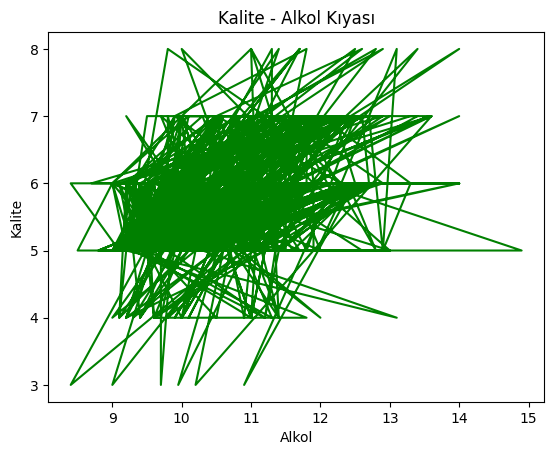

In [21]:
plt.plot("alcohol","quality","g", data = data)
plt.xlabel("Alkol")
plt.ylabel("Kalite")
plt.title("Kalite - Alkol Kıyası")
plt.show()

Basit bir matplotlib grafiği çizildi fakat istenilen alınamadı

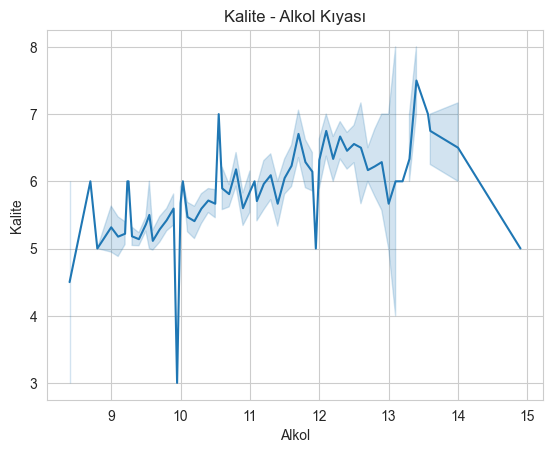

In [39]:
sns.set_style("whitegrid")
sns.lineplot(x="alcohol",y="quality", data = data)
plt.xlabel("Alkol")
plt.ylabel("Kalite")
plt.title("Kalite - Alkol Kıyası")
plt.show()

Seaborn ile daha net bir grafik elde edildi. Farklı grafikler üzerinden bakmaya devam edildi.

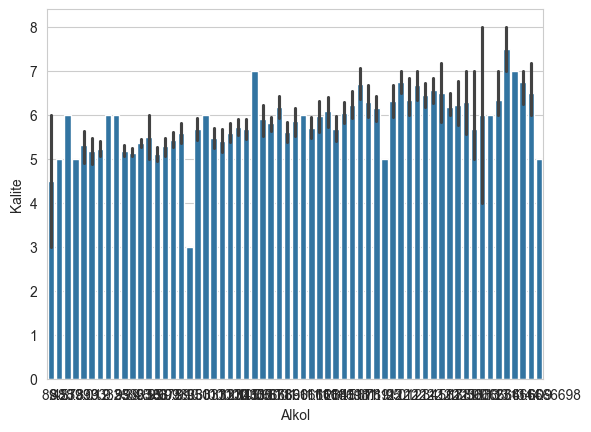

In [43]:
sns.set_style("whitegrid")
sns.barplot(x="alcohol",y="quality", data= data)
plt.xlabel("Alkol")
plt.ylabel("Kalite")
plt.show()

Bir önceki grafik daha netti. Diğer girdiler ile kalite arasındaki bağlam incelenmeye başlandı.

In [47]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

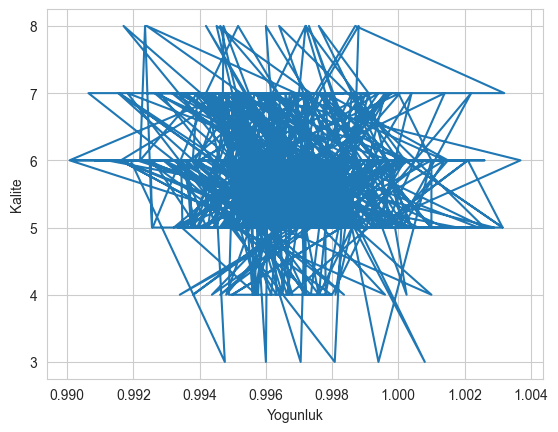

In [51]:
plt.plot("density","quality",data=data)
plt.xlabel("Yogunluk")
plt.ylabel("Kalite")
plt.show()

Kalite ile Yoğunluk arasındaki ilişki incelendi. Net bir grafik elde edilemedi.

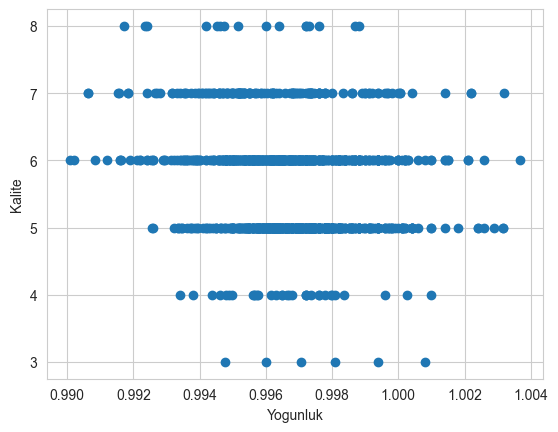

In [57]:
plt.scatter("density","quality",data=data)
plt.xlabel("Yogunluk")
plt.ylabel("Kalite")
plt.show()

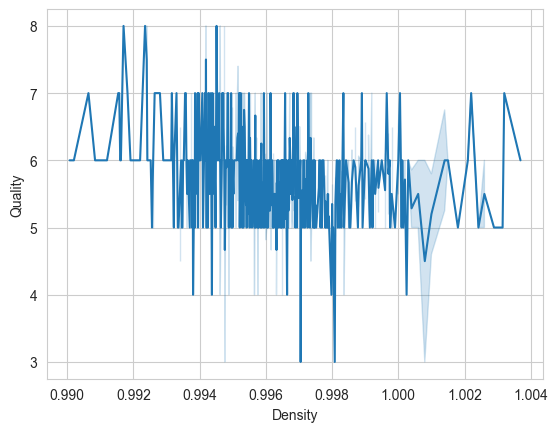

In [61]:
sns.set_style("whitegrid")
sns.lineplot(x="density",y="quality",data=data)
plt.xlabel("Density")
plt.ylabel("Quality")
plt.show()


Kalite ile Yoğunluk arasında grafiklerden net bir sonuç çıkarılamadı.

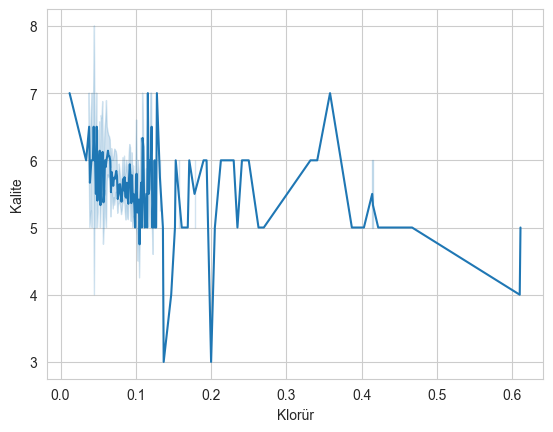

In [67]:
sns.set_style("whitegrid")
sns.lineplot(x="chlorides",y="quality",data=data)
plt.xlabel("Klorür")
plt.ylabel("Kalite")
plt.show()

Yoğunluğa göre Klorür'ün Kalite karşısında daha etkili olduğu gözlendi.

Tüm bunlar yerine korelasyon bakmaya karar verdim

In [89]:
data.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


Arasında en cok iliski bulunan iki girdi : Density ve fixed acidity,
Kaliteyi en cok etkileyen girdi Alkol.

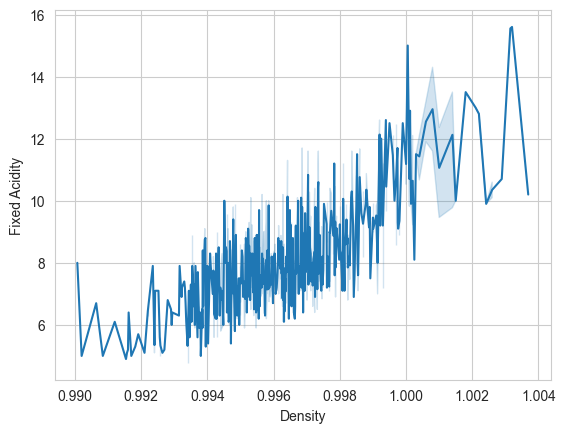

In [95]:
sns.set_style("whitegrid")
sns.lineplot(x="density",y="fixed acidity", data=data)
plt.xlabel("Density")
plt.ylabel("Fixed Acidity")
plt.show()

Merak edip Kalite ve Alkol arasındaki ilişkiyi Seaborn kullanarak tekrar inceliyorum

<Axes: >

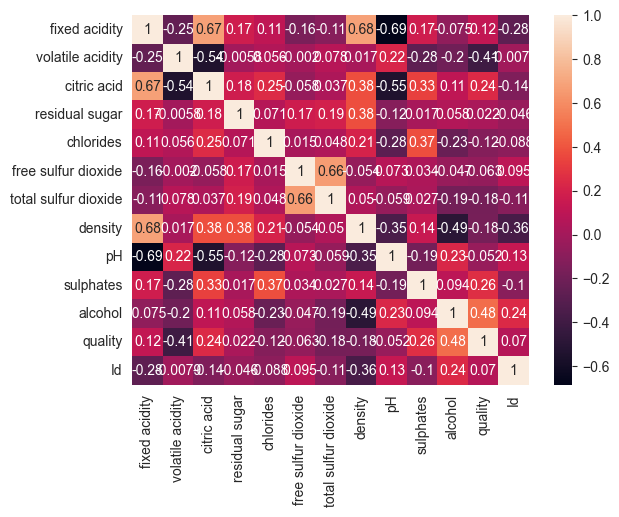

In [101]:
sns.heatmap(data.corr(numeric_only=True), annot = True)

Gözden kaçırmamak için korelasyon veri setini ısı haritası üzerinde inceledim.

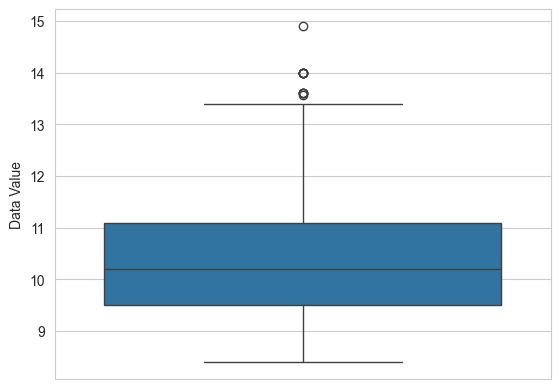

In [113]:
plt.figure()
sns.boxplot(y="alcohol", data=data)
plt.ylabel("Data Value")
plt.show()

Box Plot ile Alkol girdisinin değer aralığını kontrol ettim.

In [115]:
data["alcohol"].mean()

10.442111402741325

Ortalamayı grafik üzerinde teyit etmek için tekrar baktım.

Box Plot incelendiğinde outlier olduğu açık. Fakat standart sapmamızı çok etkilememiş.

In [121]:
data["alcohol"].describe()

count    1143.000000
mean       10.442111
std         1.082196
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64

In [127]:
data.groupby("quality").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
quality,,,,,,,,,,,,
3,8.450000,0.897500,0.211667,2.666667,0.105333,8.166667,24.500000,0.997682,3.361667,0.550000,9.691667,1121.166667
4,7.809091,0.700000,0.165758,2.566667,0.094788,14.848485,40.606061,0.996669,3.391212,0.637879,10.260606,692.848485
5,8.161077,0.585280,0.240124,2.540476,0.091770,16.612836,55.299172,0.997073,3.302091,0.613375,9.902277,753.925466
6,8.317749,0.504957,0.263680,2.444805,0.085281,15.215368,39.941558,0.996610,3.323788,0.676537,10.655339,854.625541
7,8.851049,0.393671,0.386573,2.760140,0.075217,14.538462,37.489510,0.996071,3.287133,0.743566,11.482634,830.349650
8,8.806250,0.410000,0.432500,2.643750,0.070187,11.062500,29.375000,0.995553,3.240625,0.766250,11.937500,797.875000


Şarapları kalitesine göre sınıflandırdım

In [129]:
data["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

Şarapların hangi kalite türünde kaç adet olduğuna baktım. Şaraplar çoğunlukla
ortalama kalitede üretilmiş. Çok yüksek(9,10) veya çok düşük(1,2) kalitede şarap bulunmuyor.

<Axes: xlabel='quality'>

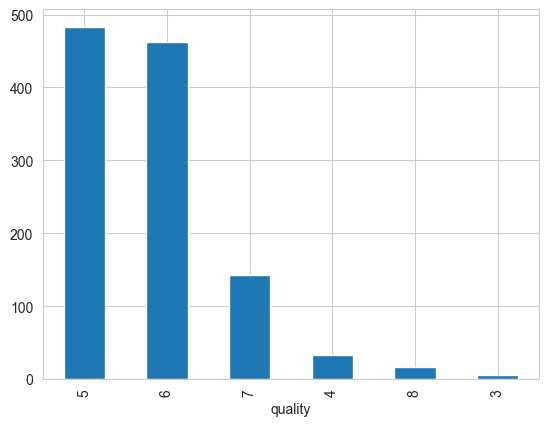

In [139]:
data["quality"].value_counts().plot(kind="bar")

Şarapların kalite sınıflandırmasını bar grafiği kullanarak inceledim.

<Axes: xlabel='alcohol', ylabel='Count'>

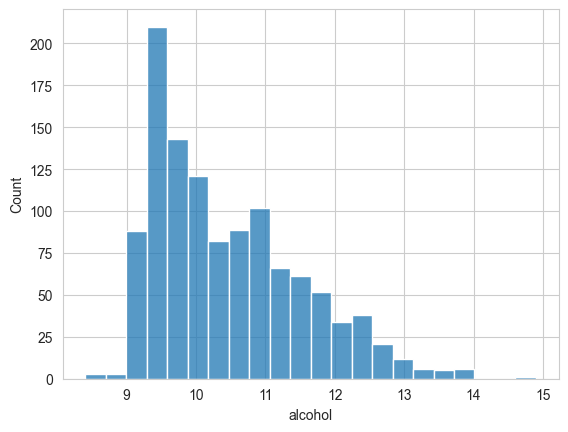

In [141]:
sns.histplot(data["alcohol"])

Alkol miktar sınıflandırmasını histogram grafiği üzerinde inceledim.

In [143]:
data["alcohol"].value_counts()

alcohol
9.500000     92
9.400000     72
9.800000     57
9.200000     50
10.000000    49
             ..
11.950000     1
9.950000      1
9.233333      1
9.250000      1
10.550000     1
Name: count, Length: 61, dtype: int64

Alkol miktarlarının adetleri için genel inceleme yaptım

## Genel Çıkarım ve Yorumlamam

Üretici firma eğerki kaliteli bir şarap istiyorsa kaliteyi en çok etkileyen girdi 'Alkol' olarak belirlendi, alkole önem verilmeli. Fakat %100 bir etkileme yok. Korelasyon incelediğimizde 0.48'lik bir değer elde ettik. Bu pozitif bir değer olmasına karşın çok belirleyici değil.

Kaliteyi etkileyen tek şey pozitif korelasyon değildir. Negatif korelasyonlarda önemlidir.

Volatile acidity ve density korelasyon değerleri negatif olarak karşımıza çıkıyor.

Üretici firma bu üç önemli girdi arasında dengeyi sağlarsa daha kaliteli şaraplar üretebilir.

Eğer ki bir model oluşturulacaksa alkol, yoğunluk ve uçucu asitlik bağımsız değişkenlerinin katsayısının diğer girdilere göre daha yüksek olacağını anlıyoruz.